<a href="https://colab.research.google.com/github/raj143sujay/EXCELR-ASSIGNMENTS/blob/main/ASSIGNMENT_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import html
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# =====================================================================
# STEP 1: DATA PREPROCESSING
# =====================================================================
print("="*70)
print("STEP 1: DATA EXPLORATION AND PREPROCESSING")
print("="*70)

# Load the dataset
df = pd.read_csv('anime.csv')
print(f"Dataset Shape: {df.shape[0]} entries, {df.shape[1]} columns")

# Check for missing values
print("\nMissing values count per column:")
print(df.isnull().sum())

# Data Cleansing Strategy:
# 1. Fill categorical missing values with 'Unknown'
# 2. Impute numeric rating missing values with the column median value
df_clean = df.copy()
df_clean['genre'] = df_clean['genre'].fillna('Unknown')
df_clean['type'] = df_clean['type'].fillna('Unknown')
df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].median())

# 3. Clean up HTML entities embedded in names (e.g., convert 'Gintama&#039;' to "Gintama'")
df_clean['name'] = df_clean['name'].apply(html.unescape)

print("\nMissing values successfully handled.")

# =====================================================================
# STEP 2: FEATURE EXTRACTION
# =====================================================================
print("\n" + "="*70)
print("STEP 2: FEATURE EXTRACTION USING TF-IDF")
print("="*70)

# Content-based recommendation engines rely on textual feature similarities (genres).
# We use TfidfVectorizer to convert textual genres into numeric vector weights.
tfidf = TfidfVectorizer(token_pattern=r'(?u)\b[\w\s-]+\b', stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_clean['genre'])

print(f"TF-IDF Matrix Dimensions: {tfidf_matrix.shape[0]} items x {tfidf_matrix.shape[1]} unique genre features")

# =====================================================================
# STEP 3: RECOMMENDATION ENGINE FUNCTION
# =====================================================================
print("\n" + "="*70)
print("STEP 3: RECOMMENDATION FUNCTION EVALUATION")
print("="*70)

def recommend_anime(title, num_recommendations=5, similarity_threshold=0.2):
    """
    Recommends similar anime based on Cosine Similarity scores of genres.
    """
    # Look up the index of the requested anime
    matched_indices = df_clean[df_clean['name'].str.lower() == title.lower()].index

    if len(matched_indices) == 0:
        return f"Error: Anime '{title}' was not located in the dataset profile database."

    idx = matched_indices[0]

    # Compute Cosine Similarity between the target anime vector and all items in matrix
    cosine_sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    # Sort indices based on similarity scores in descending order
    sorted_similar_indices = np.argsort(cosine_sim_scores)[::-1]

    # Exclude the query anime itself from the recommendation list
    sorted_similar_indices = [i for i in sorted_similar_indices if i != idx]

    # Gather recommendation records that satisfy the minimum similarity threshold filter
    recommendation_records = []
    for i in sorted_similar_indices:
        if cosine_sim_scores[i] >= similarity_threshold:
            recommendation_records.append({
                'Anime Name': df_clean.iloc[i]['name'],
                'Genre': df_clean.iloc[i]['genre'],
                'Format Type': df_clean.iloc[i]['type'],
                'Average Rating': df_clean.iloc[i]['rating'],
                'Cosine Similarity': cosine_sim_scores[i]
            })

        if len(recommendation_records) >= num_recommendations:
            break

    return pd.DataFrame(recommendation_records)

# Test recommendation output 1: Movie item
print("\nTop 5 Recommendations for 'Kimi no Na wa.' (Your Name):")
print(recommend_anime('Kimi no Na wa.', num_recommendations=5, similarity_threshold=0.5))

# Test recommendation output 2: TV Series item
print("\nTop 5 Recommendations for 'Steins;Gate':")
print(recommend_anime('Steins;Gate', num_recommendations=5, similarity_threshold=0.5))

STEP 1: DATA EXPLORATION AND PREPROCESSING
Dataset Shape: 12294 entries, 7 columns

Missing values count per column:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Missing values successfully handled.

STEP 2: FEATURE EXTRACTION USING TF-IDF
TF-IDF Matrix Dimensions: 12294 items x 44 unique genre features

STEP 3: RECOMMENDATION FUNCTION EVALUATION

Top 5 Recommendations for 'Kimi no Na wa.' (Your Name):
                              Anime Name  \
0            Wind: A Breath of Heart OVA   
1           Wind: A Breath of Heart (TV)   
2  Aura: Maryuuin Kouga Saigo no Tatakai   
3         Angel Beats!: Another Epilogue   
4                               Harmonie   

                                          Genre Format Type  Average Rating  \
0          Drama, Romance, School, Supernatural         OVA            6.35   
1          Drama, Romance, School, Supernatural          TV            6.14   
2  Comedy, 

In [3]:
def calculate_average_genre_similarity(target_genre):
    """
    Calculates the average cosine similarity score for anime within a specified genre.
    Excludes self-similarity (similarity of an anime to itself).
    """
    # Find all anime that contain the target_genre
    genre_anime_df = df_clean[df_clean['genre'].str.contains(target_genre, case=False, na=False)].copy()

    if genre_anime_df.empty:
        return f"No anime found for genre: '{target_genre}'."

    # Get the indices of these anime from the original df_clean
    genre_indices = genre_anime_df.index.tolist()

    # Extract the TF-IDF vectors for only these genre-specific anime
    tfidf_matrix_genre = tfidf_matrix[genre_indices]

    # Compute pairwise cosine similarity within this genre subset
    genre_cosine_sim_scores = cosine_similarity(tfidf_matrix_genre, tfidf_matrix_genre)

    # Exclude self-similarity (diagonal elements) and count valid pairs
    # Sum all unique pairwise similarities (upper triangle excluding diagonal)
    num_anime_in_genre = genre_cosine_sim_scores.shape[0]
    if num_anime_in_genre <= 1:
        return f"Only {num_anime_in_genre} anime found for genre '{target_genre}', cannot calculate average pairwise similarity."

    total_similarity = 0
    num_pairs = 0

    for i in range(num_anime_in_genre):
        for j in range(i + 1, num_anime_in_genre):
            total_similarity += genre_cosine_sim_scores[i, j]
            num_pairs += 1

    if num_pairs > 0:
        average_similarity = total_similarity / num_pairs
        return f"Average cosine similarity for anime in genre '{target_genre}': {average_similarity:.4f}"
    else:
        return f"Could not calculate average similarity for genre '{target_genre}'."

# Example usage:
print(calculate_average_genre_similarity('Action'))
print(calculate_average_genre_similarity('Drama'))
print(calculate_average_genre_similarity('Fantasy'))
print(calculate_average_genre_similarity('Unknown'))

Average cosine similarity for anime in genre 'Action': 0.2882
Average cosine similarity for anime in genre 'Drama': 0.3242
Average cosine similarity for anime in genre 'Fantasy': 0.3775
Average cosine similarity for anime in genre 'Unknown': 1.0000


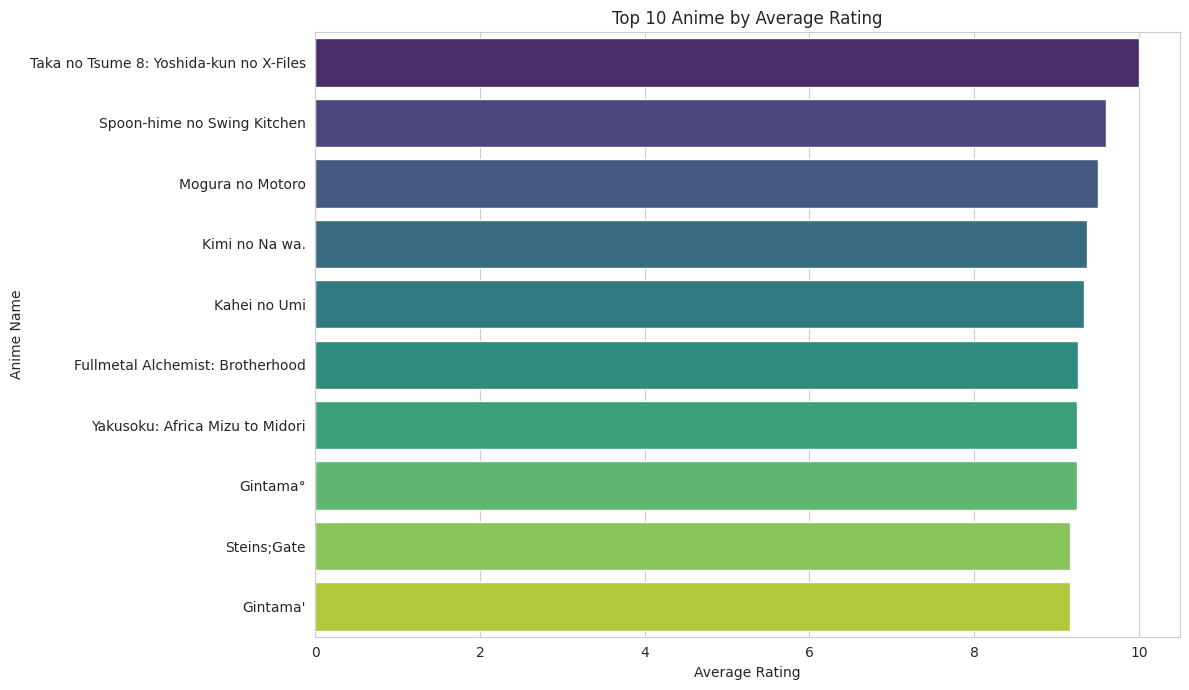

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 anime by average rating
top_10_anime = df_clean.sort_values(by='rating', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='rating', y='name', data=top_10_anime, palette='viridis', hue='name', legend=False)
plt.title('Top 10 Anime by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Anime Name')
plt.tight_layout()
plt.show()

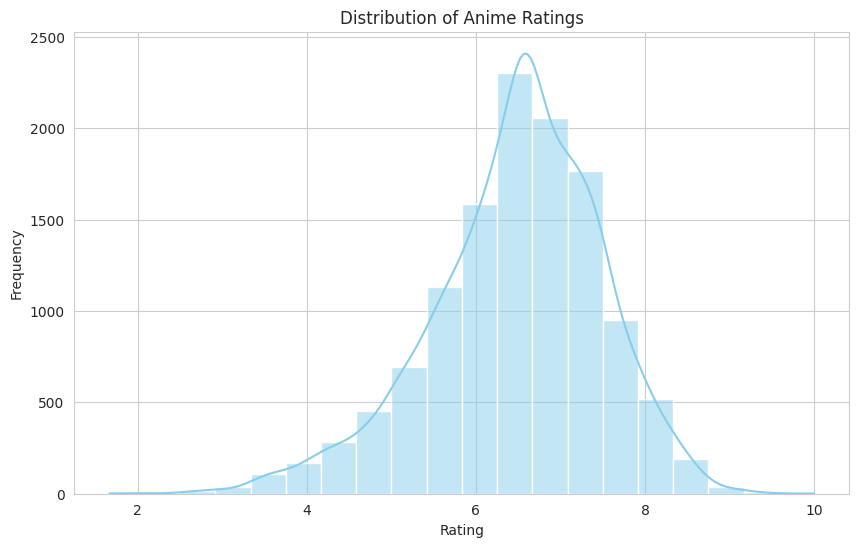

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Anime Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

Can you explain the difference between user-based and item-based collaborative filtering?

User-based collaborative filtering: This approach identifies users who are similar to the target user (e.g., they have rated similar items highly). Once similar users are found, items that these similar users liked but the target user hasn't seen are recommended to the target user. It's often summarized as "Users who are like you liked these items."
Item-based collaborative filtering: This approach identifies items that are similar to items the target user has already liked. Similarity between items is often determined by looking at users who have rated both items. If many users who liked item A also liked item B, then item B is considered similar to item A. It's often summarized as "If you liked this item, you might like these other similar items."
What is collaborative filtering, and how does it work?

Collaborative filtering is a technique used by recommendation systems to make automatic predictions (filtering) about the interests of a user by collecting preferences or taste information from many users (collaborating). The underlying assumption is that if a person A has the same opinion as a person B on a set of items, A is more likely to have B's opinion on a different item than that of a randomly chosen person.
How it works: It essentially builds a model of users' past behavior (e.g., ratings, purchases, views) and makes predictions based on the preferences of other users. There are generally two main types (as mentioned above): user-based and item-based. Both rely on finding patterns of similarity—either between users or between items—to generate recommendations without needing any explicit information about the items themselves (like genre or content)
